In [1]:

'''
Read data the following data:
    - pkt_count: logs the # of packets in each word bin by channel
    - too_few: logs the # of word bins with < 2 packets by channel

from a file previously created by the code "linearity_get_data". This data was 
obtained by putting a sweep of voltages (1.8V to 0) into the ADC bypassing the CSA. 
These voltages should result in a good dataword range from 200 to 800 or so. 
Graph various quantities which will:
    - flag any channels that are grossly non-linear
    - indicate the adequacy of the run setup for the purpose of this test
    
Only set 4 (cold) had non-problematic data. There must have been a problem in the test set-up 
    for sets 2 and 3 (cold)

Warm data was only taken for set 2

'''

import h5py
import matplotlib.pyplot as plt
import yaml
import numpy as np
import argparse
import json
import tqdm
import io
import tarfile
import os
import math
import tqdm
import re

from tqdm import tqdm
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from statistics import mean, mode, stdev
from pathlib import Path
from datetime import datetime

##########################################################
# Initialize parameters  
##########################################################

# set 4: tiles 1, 2, 5 and 9 had faulty data due to an error in the run procedure.
#filename = f"../data/BAD_linearity_data_cold_tile9_4K03329_9.77_2.37ramp_60m.hdf5"
#filename = f"../data/BAD_linearity_data_cold_tile2_4k02056_9.77_2.37ramp_73m.hdf5"

# sets 2 and 3 had a problem across all tiles in their cold data. Only words between ~500 and 800 had data.
# Results will not be logged for sets 2 and 3
#filename = f"../data/BAD_linearity_data_cold_tile10_4K00770_9.77_2.37ramp_60m.hdf5"
#filename = f"../data/BAD_linearity_data_cold_tile8_4K04411_9.77_2.37ramp_60m.hdf5"
#filename = "../data/BAD_linearity_data_cold_tile2_4k04905_9.77_2.37ramp_119m.hdf5"
#filename = f"../data/BAD_linearity_data_cold_tile1_4k04582_9.77_2.37ramp_120m.hdf5"

# warm data from set 2 varied the amount of data taking time and the ramp speeds
#filename = f"../data/linearity_data_warm_tile2_4k03591_120ramp_39m.hdf5"
#filename = f"../data/linearity_data_warm_tile2_4k03591_120ramp_39m.hdf5"
#filename = f"../data/linearity_data_warm_tile2_4k03591_9.77_2.37_19m.hdf5"
#filename = f"../data/linearity_data_warm_tile2_4k03591_9.77_2.37ramp_40m.hdf5"

# set 4 cold linearity data. These are the only cold run files with good linearity data.
#filename = f"../data/linearity_data_cold_tile3_4k02219_9.77_2.37ramp_60m.hdf5"
#filename = f"../data/linearity_data_cold_tile4_4k02371_9.77_2.37ramp_60m.hdf5"
#filename = f"../data/linearity_data_cold_tile6_4k04834_9.77_2.37ramp_60m.hdf5"
#filename = f"../data/linearity_data_cold_tile7_4k00101_9.77_2.37ramp_60m.hdf5"
#filename = f"../data/linearity_data_cold_tile8_4K00277_9.77_2.37ramp_60m.hdf5"
filename = f"../data/linearity_data_cold_tile10_4K03496_9.77_2.37ramp_60m.hdf5"

# temp records if test was conducted cold (typically in LN) or warm (room temp)
if "warm" in filename:
    temp = "warm"
elif "cold" in filename:
    temp = "cold"
else:
    print(f"The filename did not indicate if this was a cold or warm run")
    temp = "warm/cold not indicated"

# set the range of datawords to test
max_dataword = 750
min_dataword = 300

total_n_dnl_graphs = 5
total_n_bad_stdev = 2
total_n_all_words = 10

# initialize
ig = 1 
mean_npkts = 0
n_dnl_graphed = 0
n_bad_stdev_graphed = 0
n_all_words_graphed = 0

# background: packet dataset attributes: 
# ('io_group', 'io_channel', 'chip_id', 'packet_type', 'downstream_marker', 'parity', 'valid_parity', 'channel_id', 
# 'timestamp', 'dataword', 'trigger_type', 'local_fifo', 'shared_fifo', 'register_address', 'register_data', 'direction', 
# 'local_fifo_events', 'shared_fifo_events', 'counter', 'fifo_diagnostics_enabled', 'first_packet', 'receipt_timestamp')


In [2]:
def get_io_channels(tile):

    io_ch_per_tile = [
        [],
        [1,2,3,4],
        [5,6,7,8],
        [9,10,11,12],
        [13,14,15,16],
        [17,18,19,20],
        [21,22,23,24],
        [25,26,27,28],
        [29,30,31,32],
        [33,34,35,36],
        [37,38,39,40]
        ]
    
    return io_ch_per_tile[tile]


In [3]:
def kurtosis(data):
    """
    Calculate kurtosis (Fisher definition) for 1 channel.
    """
    
    data = np.array(data, dtype=float)
    n = len(data)
    
    # Calculate kurtosis 
    if n > 4:
        kurt = scipy.stats.kurtosis(data, axis = 0, fisher = True, bias = True)
    else:
        kurt = 1E8
    
    return kurt

In [4]:
def find_best_and_worst():
    
    global pkt_count, too_few, best_chip, worst_chip

    lowest_few  = 1E7
    most_few = 0
    best_chip = 0
    worst_chip = 0
    
    # find best and worst word-bin populated chips
    for chip in range(11,171):

        too_few_chip = 0
        
        for chan in range(0,64):
            too_few_chip = too_few_chip + too_few[chip][chan]

        if too_few_chip < lowest_few:
            best_chip = chip
            lowest_few = too_few_chip
            
        if too_few_chip > most_few:
            worst_chip = chip
            most_few = too_few_chip

    if best_chip > 0:
        print(f"\nBest  Chip {best_chip } had {lowest_few} word bins w < 2 pkts")
    else:
        print(f"\nNo best chip could be found")

    if worst_chip > 0:    
        print(f"\nWorst Chip {worst_chip} had {most_few } word bins w < 2 pkts, among its channels:")    
    else:
        print(f"\nNo worst chip could be found")
        
    lowest_few  = 1000
    most_few = -1
    best_chan = 100
    worst_chn = 100
    
    # find best and worst channels on worst chip    
    for chan in range(0,64):
        
        if too_few[worst_chip][chan] < lowest_few:
            best_chan = chan
            lowest_few = too_few[worst_chip][chan]

        if too_few[worst_chip][chan] > most_few:
            worst_chan = chan
            most_few = too_few[worst_chip][chan]

    if best_chan < 100:
        print(f"\tBest  Channel {best_chan } had {lowest_few} bins w < 2 pkts")
    else:
        print(f"\nNo best channel could be found")

    if worst_chan < 100:    
        print(f"\tWorst Channel {worst_chan} had {most_few } bins w < 2 pkts")    
    else:
        print(f"\nNo worst channel could be found")   
    
    return best_chip, worst_chip, best_chan, worst_chan


In [5]:
def graph_tile(tile):

    global pkt_count, too_few, ramp, chip_serial_number, temp, mean_npkts

    too_few_list, chip_list = [], []
    
    for chip in range(11,171):
        count_list = np.array(too_few[chip]).flatten()
        too_few_list.append(np.sum(count_list))
        chip_list.append(chip)

    npkts_all = np.array(pkt_count).flatten()
    non_zero_npkts = npkts_all[npkts_all != 0]
    
    mean_npkts = np.mean(non_zero_npkts)
    mode_npkts = mode(non_zero_npkts)
    
    print(f"\nMean Non-Zero # of Packets in each word bin {mean_npkts:.1f}")       
    print(f"\nMode Non-Zero # of Packets in each word bin {mode_npkts}") 
    
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.hist(npkts_all, bins=max(npkts_all))
    ax.set_title(f'# Packets in All Word Bins on Tile {tile}\nMean {mean_npkts:.1f}, Mode {mode_npkts}\n {ramp}s Voltage Sweep, v3a Tile #{tile} ({chip_serial_number})')
    ax.set_xlabel(f'Number of Packets')
    ax.set_ylabel(f'# Word Bins')
    ax.set_yscale("log")
    plt.show 
    
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.scatter(chip_list, too_few_list)
    ax.set_title(f'# Word Bins w < 2 pkts by Chip on Tile {tile}\n {ramp}s Voltage Sweep, v3a Tile #{tile} ({chip_serial_number})')
    ax.set_xlabel(f'Chip')
    ax.set_ylabel(f'# Word Bins w < 2 pkts')
    plt.show 
    
    flatten_by_chip = np.array(too_few).flatten()
    too_few_list = flatten_by_chip.flatten()
    
    mx = max(too_few_list)
    mn = min(too_few_list)
    print(f"The smallest # of word-bins with too few packets in 1 channel = {mn}")
    print(f"The largest  # of word-bins with too few packets in 1 channel = {mx}")
    n_bins = int(mx - mn +1)  
          
    fig, ax = plt.subplots(1,2, figsize=(14, 3))
    ax[0].hist(too_few_list, bins=n_bins)
    ax[0].set_title(f'# Word Bins w < 2 pkts per Channel on Tile {tile}\n {ramp} ramp Voltage Sweep, v3a Tile #{tile} ({chip_serial_number})')
    ax[0].set_xlabel(f'# Word Bins < 2 pkts')
    ax[0].set_ylabel(f'Channel Count')
    ax[0].set_yscale("log")

    ax[1].hist(too_few_list, bins=n_bins)
    ax[1].set_title(f'Zoom into # Word Bins w < 2 pkts per Channel on Tile {tile}\n {ramp} ramp Voltage Sweep, v3a Tile #{tile} ({chip_serial_number})')
    ax[1].set_xlabel(f'# Word Bins < 2 pkts')
    ax[1].set_xlim(0,20)
    ax[1].set_yscale("log")
    
    plt.show 


In [6]:
def graph_chip(tile, chip, quality):
    
    global pkt_count, too_few, chip_serial_number
    
    too_few_list, chan_list = [],[]
    
    for chan in range(0,64):
    
        too_few_list.append(too_few[chip][chan])
        chan_list.append(chan)
    
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(chan_list, too_few_list)
    ax.set_title(f'Word-bins w < 2 pkts by Channel on {quality} Chip {chip}\nTest of v3a Tile #{tile} ({chip_serial_number})')
    ax.set_xlabel(f'Channel')
    ax.set_ylabel(f'# Word-bins w < 2 pkts')
    plt.show                 

    return

In [7]:
def graph_channel(tile, chip, chan, quality):

    global pkt_count, chip_serial_number, max_dataword, min_dataword
    
    count_list, word_list = [],[]

    looking = True
    
    # find the first word bin that has data using "looking"
    for word in range(min_dataword, max_dataword):

        if pkt_count[chip][chan][word] > 0 and looking:
            looking = False

        if not looking:
            count_list.append(pkt_count[chip][chan][word])
            word_list.append(word)
    
    if len(count_list) > 2:
    
        n_low = sum(1 for x in count_list if x<2)
    
        mean_count = np.mean(count_list)
        std_count  = np.std(count_list)
        min_count  = min(count_list)
        max_count  = max(count_list)
    
        nbins = max_count - min_count +1
        
        fig, ax = plt.subplots(1,2, figsize=(14, 3))
    
        ax[0].plot(word_list, count_list, marker = 'o', linestyle = '')
        ax[0].set_title(f'# Pkts in Word bins for {quality} Channel {chan} on Chip {chip}\n{n_low} bins have < 2pkts, Test of v3a Tile #{tile} ({chip_serial_number})')
        ax[0].axhline(y = mean_count, color='r', linestyle='-', linewidth=2) 
        ax[0].axhline(y = mean_count+std_count, color='r', linestyle='--', linewidth=2) 
        ax[0].axhline(y = 0, color='r', linestyle='--', linewidth=2)         
        ax[0].set_xlabel(f'ADC Dataword')
        ax[0].set_ylabel(f'# Packets')
        
        ax[1].hist(count_list, bins = nbins)
        ax[1].set_title(f'# Pkts in Word bins for {quality} Channel {chan} on Chip {chip}\n{n_low} bins have < 2pkts, Test of v3a Tile #{tile} ({chip_serial_number})')
        ax[1].axvline(x = mean_count, color='r', linestyle='-', linewidth=2) 
        ax[1].axvline(x = mean_count+std_count, color='r', linestyle='--', linewidth=2) 
        ax[1].axvline(x = 0, color='r', linestyle='--', linewidth=2)         
        ax[1].set_xlabel(f'# Packets')
        ax[1].set_ylabel(f'Dataword Count')
    
        plt.show
    
    return    

In [8]:
def get_std_pkt_count(tile):
    
    global pkt_count, ramp, chip_serial_number, min_dataword, max_dataword

    std_list = []
    
    for chip in range(62,63):
        for chan in range(0,64):
            word_counts = []
            for word in range(min_dataword, max_dataword):
                word_counts.append(pkt_count[chip][chan][word])
            #word_counts = np.array(pkt_count[chip][chan]).flatten()
            std_chan = np.std(word_counts)
            std_list.append(std_chan)

    mx = max(std_list)
    mn = min(std_list)
    
    fig, ax = plt.subplots(1,2, figsize=(14, 3))

    ax[0].hist(std_list, bins = 100)
    ax[0].set_title(f'Stdev(Word Bin Count) per Channel on Tile {tile}\n {ramp} ramp Voltage Sweep, v3a Tile #{tile} ({chip_serial_number})')
    ax[0].set_xlabel(f'Stdev(Word Bin Count)')
    ax[0].set_ylabel(f'Channel Count')
    ax[0].set_yscale("log")

    ax[1].hist(std_list, bins = 100)
    ax[1].set_title(f'Stdev(Word Bin Count) per Channel on Tile {tile}\n {ramp} ramp Voltage Sweep, v3a Tile #{tile} ({chip_serial_number})')
    ax[1].set_xlabel(f'Stdev(Word Bin Count)')
    ax[1].set_yscale("log")
    ax[1].set_xlim(0,25)
    
    plt.show 

In [9]:
def read_data():

    global pkt_count, too_few, filename

    with h5py.File(filename, 'r') as f:
            
        too_few   = f['too_few'][:]
        pkt_count = f['pkt_count'][:]        
        
        f.close()  

    print(f"\n\nData read from {filename}\n\n")
    
    return    

In [10]:
def get_dnl_inl(tile):

    global pkt_count, chip_serial_number, temp, min_dataword, max_dataword, n_dnl_graphed, n_chans, temp
    global total_n_dnl_graphs, total_n_bad_stdev, n_bad_stdev_graphed, filename, results, tile_index
    global total_n_all_words, n_all_words_graphed
    
    stdev_inl_list = []
    zero_word_list, zero_chan_list, zero_chip_list = [],[],[]
    bad_dnl_chan_list, bad_dnl_chip_list = [],[]
    final_inl_list = []
    word_list, dnl, inl = [],[], []
    quality_list = []
    npkts_list = []
    good_chip = 0
    large_dnl = 0
    n_bins, n_chans, n_bad_dnl_chans, n_chans_no_missing_words = 0, 0, 0, 0
    npkts_in_range = 0
    count_at_512, total_count, small_dnl = 0,0,0
    
    for chip in tqdm(range(11,171), desc = "calculating INL by chip"):
        
        n_zero_pkts = 0
        
        for chan in range(64):
            
            npkts_in_range = 0
            
            npkts = sum(np.array(pkt_count[chip][chan]).flatten())
            
            found_missing_word_near_512 = False

            if npkts > 0:
                
                word_list, dnl, inl = [],[], []
                looking = True
                n_chans += 1
                good_dnl = True
                no_missing_words = True
                numb_missing_words = 0

                # find the first and last word bins that have data within the requested range
                for word in range(min_dataword, max_dataword):

                    max_chan_word =  max_dataword
                    
                    if pkt_count[chip][chan][word] > 0:
                        if looking:
                            looking = False
                            min_chan_word = word
                            npkts_in_range += pkt_count[chip][chan][word]

                        else:
                            max_chan_word = word
                            npkts_in_range += pkt_count[chip][chan][word]
                    
                    # retain information on words with no packets
                    else:
                        zero_chip_list.append(chip)
                        zero_chan_list.append(chan)
                        zero_word_list.append(word)
                        no_missing_words = False

                        numb_missing_words +=1

                        if word ==511 or word <= 512 and not found_missing_word_near_512:
                            count_at_512 += 1 
                            found_missing_word_near_512 = True

                        total_count +=1
                
                # get the mean # of packets for this channel
                expected_npkts = npkts_in_range / (max_chan_word - min_chan_word)
                if no_missing_words:
                    n_chans_no_missing_words +=1

                    if n_all_words_graphed < total_n_all_words:
                        n_all_words_graphed +=1
                        graph_channel(tile, chip, chan , "All-word-bins")                       
                
                # calculate DNL and INL (which is the cumulative sum of DNL)
                for word in range(min_chan_word, max_chan_word):

                    # DNL indicates whether a given word bin has more or less than the expected # of packets, 
                    # where the expected # is given by the mean # of packets in word bins for the given channel 
                    dnl.append((pkt_count[chip][chan][word] - expected_npkts)/expected_npkts)
                    word_list.append(word)
                    inl.append(sum(dnl))

                    if dnl[-1] > 1:
                        large_dnl +=1 
                        good_dnl = False
                    else:
                        small_dnl +=1

                    n_bins +=1
                
                # determine the stdev from a line fit through the first and last inl values
                slope = (inl[-1] - 0) / (word_list[-1] - word_list[0])
                stdev_inl = 0
                
                for w in range(1,len(word_list)):
                    fit_word = (word_list[w] - word_list[0]) * slope
                    stdev_inl += ( inl[w] - fit_word )**2
                    
                stdev_inl_list.append(( stdev_inl / len(word_list) )**0.5 )
                npkts_list.append(npkts_in_range)
                final_inl_list.append(inl[-1])

                # store the results from files that are not BAD in the results dictionary for all tiles
                if "BAD" not in filename:

                    results["inl"][tile_index][chip][chan] =  final_inl_list[-1]
                    results["dnl"][tile_index][chip][chan] =  max(dnl)
                    results["inl_std"][tile_index][chip][chan] =  stdev_inl_list[-1]                    
                    results["missing_words"][tile_index][chip][chan] = numb_missing_words
                
                if not good_dnl:
                    n_bad_dnl_chans +=1
                    bad_dnl_chan_list.append(chan)
                    bad_dnl_chip_list.append(chip)
                    
                # Root Mean Square for final inl and stdev from fit line               
                quality_list.append( ( (stdev_inl_list[-1]**2 + final_inl_list[-1]**2) / 2 )**0.5 )

                if n_dnl_graphed < total_n_dnl_graphs:

                    n_dnl_graphed +=1

                    fig, ax = plt.subplots(figsize=(6, 3))
                    ax.scatter(word_list, dnl)
                    ax.set_title(f'DNL for Chip-Chan {chip}-{chan}\n{temp} test of v3a Tile #{tile} ({chip_serial_number})')
                    ax.set_xlabel(f'Dataword')
                    ax.axhline(y = 1, color='r', linestyle='--')
                    ax.set_ylabel(f'(# pkts - # expected) / # expected')
                    plt.show 
                    
                    fig, ax = plt.subplots(figsize=(6, 3))
                    ax.plot(word_list, inl)
                    ax.set_xlim(min_chan_word-10, max_chan_word+10)
                    ax.plot( [word_list[0], word_list[-1]], [0,inl[-1]], linestyle = "--", color = 'r')
                    ax.set_title(f'INL for Chip-Chan {chip}-{chan} (Stdev {stdev_inl_list[-1]:.1f}), final INL {inl[-1]:.1f}\n{temp} test of v3a Tile #{tile} ({chip_serial_number})')
                    ax.set_xlabel(f'Dataword')
                    ax.set_ylabel(f'Cumulative Sum of DNL')
                    plt.show

                # plot a few cases of acceptable INL, but broad Stdev
                if n_bad_stdev_graphed < total_n_bad_stdev and final_inl_list[-1] > -1 and stdev_inl_list[-1] > 4:

                    n_bad_stdev_graphed +=1

                    fig, ax = plt.subplots(figsize=(6, 3))
                    ax.scatter(word_list, dnl)
                    ax.set_title(f'DNL for Chip-Chan {chip}-{chan}\n{temp} test of v3a Tile #{tile} ({chip_serial_number})')
                    ax.set_xlabel(f'Dataword')
                    ax.axhline(y = 1, color='r', linestyle='--')
                    ax.set_ylabel(f'(# pkts - # expected) / # expected')
                    plt.show 
                    
                    fig, ax = plt.subplots(figsize=(6, 3))
                    ax.plot(word_list, inl)
                    ax.set_xlim(min_chan_word-10, max_chan_word+10)
                    ax.plot( [word_list[0], word_list[-1]], [0,inl[-1]], linestyle = "--", color = 'r')
                    ax.set_title(f'INL for Chip-Chan {chip}-{chan} (Stdev {stdev_inl_list[-1]:.1f}), final INL {inl[-1]:.1f}\n{temp} test of v3a Tile #{tile} ({chip_serial_number})')
                    ax.set_xlabel(f'Dataword')
                    ax.set_ylabel(f'Cumulative Sum of DNL')
                    plt.show
            
            else:
                n_zero_pkts +=1

    good_linearity = sum(1 for x in quality_list if x <= 1.0)
    
    percent_linear = 100 * good_linearity / len(quality_list)

    percent_missing_512 = 100 * count_at_512 / total_count

    percent_large_dnl_values = 100 * large_dnl / (large_dnl + small_dnl)
    percent_no_missing_words = 100 * n_chans_no_missing_words / n_chans
    percent_large_dnl_chans = 100 * n_bad_dnl_chans / n_chans
    
    print(f"\n{percent_linear:.0f}% of channels are linear, where linearity requires the RMS(final INL, Stdev from Fit Line) < 1")
    print(f"\n{percent_missing_512:.0f}% of channels are missing at least 1 dataword between 511-512")
    print(f"\n{percent_large_dnl_chans:.2f}% of channels have DNL > 1")
    print(f"\n{n_chans_no_missing_words} channels ({percent_no_missing_words:.4f}%) have no missing words between {min_dataword} and {max_dataword}") 
    print(f"\n{n_zero_pkts} channels have no data")
    print(f"\n{percent_large_dnl_values:.1f}% of DNL values were > 1, across all channels on Tile {tile}")
    mean_stdev = np.mean(stdev_inl_list)
    mean_final = np.mean(final_inl_list)

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.scatter(stdev_inl_list, final_inl_list, alpha = 0.03)
    ax.set_title(f'Final INL versus Stdev from Fit Line ({percent_linear:.0f}% linear)\nlinearity requires RMS(Final INL, Stdev from Fit Line) < 1\n{temp} test of v3a Tile #{tile} ({chip_serial_number})')
    ax.set_xlabel(f'Stdev from Line fit through 0 to last DNL')
    ax.axhline(y = -1, color='r', linestyle='--')
    ax.set_xlim(0,6)
    ax.set_ylim(-6, 0)
    ax.axvline(x = 1, color='r', linestyle='--')      
    ax.set_ylabel(f'Final INL')
    plt.show 

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.scatter(npkts_list, stdev_inl_list, alpha = 0.03)
    ax.set_title(f'Stdev from INL Line fit from 0 to Last DNL versus # Pkts in Channel\nMean Stdev {mean_stdev:.1f}, {temp} test of v3a Tile #{tile} ({chip_serial_number})')
    ax.set_xlabel(f'# of Packets in Channel')
    ax.axhline(y = -1, color='r', linestyle='--') 
    ax.axvline(x = 1, color='r', linestyle='--')     
    ax.set_ylabel(f'Stdev from INL Line')
    ax.set_xlim(0,10)
    ax.set_ylim(0, 6)
    plt.show 
    
    mean_quality = np.mean(quality_list)
    
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.hist(quality_list, bins = 100)
    ax.axvline(x = 1, color='r', linestyle='--')     
    ax.set_title(f'RMS(Final INL, Stdev from Line fit 1st to last INL)\n {percent_linear:.0f}% of Channels have RMS < 1\n{temp} test of v3a Tile #{tile} ({chip_serial_number})')
    ax.set_xlabel(f'Root Mean Square of Final INL & Stdev from Fit Line')
    plt.show 
    
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.scatter(zero_word_list, zero_chan_list, alpha = 0.04)
    ax.set_xlim(min_chan_word, max_chan_word)
    ax.set_title(f'Words with No Packets by Channel\n{temp} test of v3a Tile #{tile} ({chip_serial_number})')
    ax.set_xlabel(f'Dataword Bins with No Packets')
    ax.set_ylabel(f'Channel')
    plt.show 

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.scatter(zero_chip_list, zero_chan_list, alpha = 0.04)
    ax.set_title(f'Chip and Channel for Words w No Packets\n{temp} test of v3a Tile #{tile} ({chip_serial_number})')
    ax.set_xlabel(f'Chip')
    ax.set_ylabel(f'Channel')
    plt.show    

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.scatter(bad_dnl_chip_list, bad_dnl_chan_list, alpha = 0.2)
    ax.set_title(f'Chips and Channels with DNL > 1\n{temp} test of v3a Tile #{tile} ({chip_serial_number})')
    ax.set_xlabel(f'Chip')
    ax.set_ylabel(f'Channel')
    plt.show        
    
    return


In [11]:
# import the dictionary which logs test results by channel for all v3a tests
def import_results_dictionary():

    global results, tile_result_keys, results_filename, temp

    # serial #s uniquely identifying the chip located in the top left corner of each tile, when looking at it with 
    # the power and data connectors at the top. The following key is needed when storing results in the dictionary
    tile_result_keys = ['', '4k04582', '4k04905', '4k03080', '4k04087', '4k04249', '4k00104', '4k01300', '4K04411', '4K01733', '4K00770', \
                     '4k00952', '4k03591', '4k03936', '4k00607', \
                     '4k01892', '4k02056', '4k02219', '4k02371', '4k00450', '4k04834', '4k00101', '4K00277', '4K03329', '4K03496']
    
    # establish filename that holds the results dictionary
    first_tile = 1
    last_tile = 24
    chip_version  = "v3a"
    date = "2026-06-29_08:29"
    results_filename = f'/data/v3/10x16/results_{chip_version}_tiles_{first_tile}-{last_tile}_{temp}_created_{date}.hdf5'

    with h5py.File(results_filename, "r") as f:
        results = {}
        for key, item in f.items():
            data = item[()]
            results[key] = data    

    print(f'Results dictionary read from file {results_filename}')
    print(f'Metrics in results dictionary:\n\t{list(results.keys())}')    
          
    return

In [12]:
def store_results():

    global results, results_filename
    
    with h5py.File(results_filename, 'w') as f:
        
        for key, chan_list in results.items():
            f.create_dataset(key, data=np.array(chan_list))
    
        f.close()  

    print(f"\nResults logged in {results_filename} using raw data from: \n\t{filename}")  
    print(f'\nMetrics in results dictionary:\n\t{list(results.keys())}\n\n')

In [13]:
'''
This function extracts the tile ID, the ramp speed, and the results dictionary tile index from
the filename

'''

def get_file_details(filename):

    global chip_serial_number, tile, tile_index, ramp
    
    if not isinstance(filename, str):
        raise ValueError("Input into get_file_details(filename) must be a string version of the filename")
        return
    
    # read the chip_serial_number (i.e. each tile's unique id from the filename
    match = re.search(r'(\dK\d{5,})', filename, re.IGNORECASE)
    chip_serial_number = match.group(1)
    
    # get the tile # from the filename
    match = re.search(r'tile(\d+)', filename)
    if match:
        tile = match.group(1)  # Extract the digits after "tile"
    else:
        print("No tile number found.")
    
    # the results dictionary uses different tile ids because it has to store all 24 tiles 
    # (each raw data set only numbers tiles 1-10 
    if chip_serial_number in tile_result_keys:
        tile_index = tile_result_keys.index(chip_serial_number)
    else:
        print(f"\nProblem: tile {chip_serial_number} was not found in the results dictionary tile list. Its results will not be stored")         

    # get the ramp speeds from the filename. Regex: match two floats separated by underscore
    match = re.search(r'(\d+\.\d+_\d+\.\d+)', filename)    
    if match:
        ramp = match.group(1)
    else:
        print("Ramp not found.")

    print(f"\tAnalyzing data from tile {tile} ({chip_serial_number}) with tile index {tile_index} in results dictionary")
    print(f"\tRamp period = {ramp}")
    
    return

Results dictionary read from file /data/v3/10x16/results_v3a_tiles_1-24_cold_created_2026-06-29_08:29.hdf5
Metrics in results dictionary:
	['chip_extra_ticks', 'clock_jitter', 'dnl', 'gain', 'hot_channel', 'hydra_failure', 'inl', 'inl_std', 'invalid_parity', 'leakage_mean', 'leakage_scaling', 'leakage_stdev', 'misnumbered_chip', 'missing_syncs', 'missing_words', 'ped_full_width', 'pedestal_hot_channel', 'pedestal_kurtosis', 'pedestal_mean', 'pedestal_skew', 'pedestal_stdev', 'timing_duplicates', 'timing_pkt_percent']
	Analyzing data from tile 10 (4K03496) with tile index 24 in results dictionary
	Ramp period = 9.77_2.37


Data read from ../data/linearity_data_cold_tile10_4K03496_9.77_2.37ramp_60m.hdf5



Mean Non-Zero # of Packets in each word bin 9.9

Mode Non-Zero # of Packets in each word bin 10
The smallest # of word-bins with too few packets in 1 channel = 0
The largest  # of word-bins with too few packets in 1 channel = 525


calculating INL by chip:   1%|▏                 | 2/160 [00:00<00:34,  4.56it/s]/tmp/ipykernel_3467791/3114311049.py:30: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1,2, figsize=(14, 3))
calculating INL by chip: 100%|████████████████| 160/160 [00:26<00:00,  6.13it/s]



70% of channels are linear, where linearity requires the RMS(final INL, Stdev from Fit Line) < 1

37% of channels are missing at least 1 dataword between 511-512

24.14% of channels have DNL > 1

367 channels (3.5840%) have no missing words between 300 and 750

0 channels have no data

1.3% of DNL values were > 1, across all channels on Tile 10

Results logged in /data/v3/10x16/results_v3a_tiles_1-24_cold_created_2026-06-29_08:29.hdf5 using raw data from: 
	../data/linearity_data_cold_tile10_4K03496_9.77_2.37ramp_60m.hdf5

Metrics in results dictionary:
	['chip_extra_ticks', 'clock_jitter', 'dnl', 'gain', 'hot_channel', 'hydra_failure', 'inl', 'inl_std', 'invalid_parity', 'leakage_mean', 'leakage_scaling', 'leakage_stdev', 'misnumbered_chip', 'missing_syncs', 'missing_words', 'ped_full_width', 'pedestal_hot_channel', 'pedestal_kurtosis', 'pedestal_mean', 'pedestal_skew', 'pedestal_stdev', 'timing_duplicates', 'timing_pkt_percent']




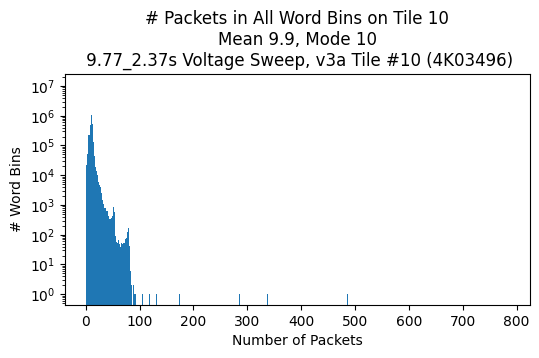

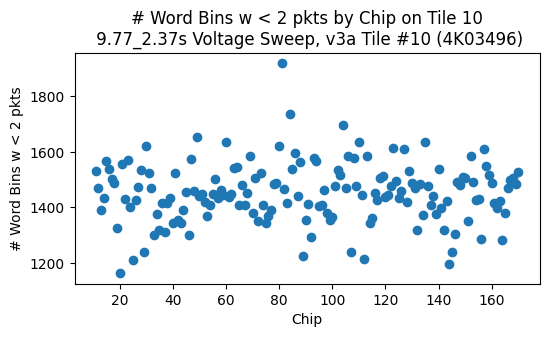

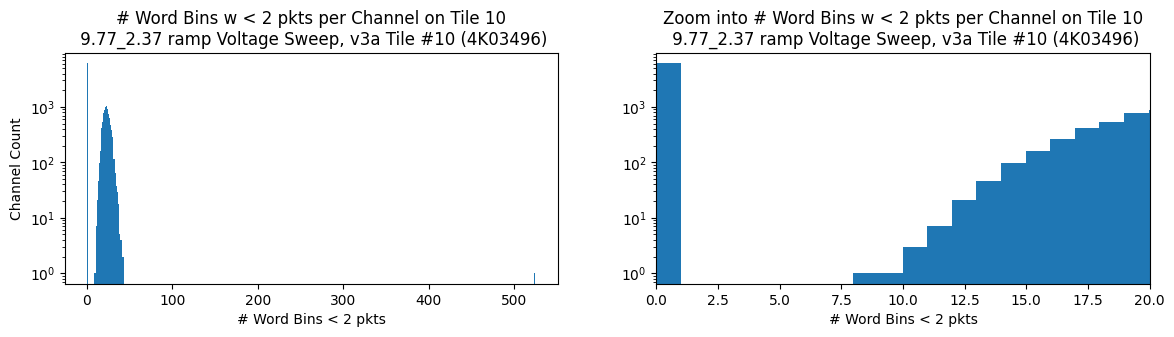

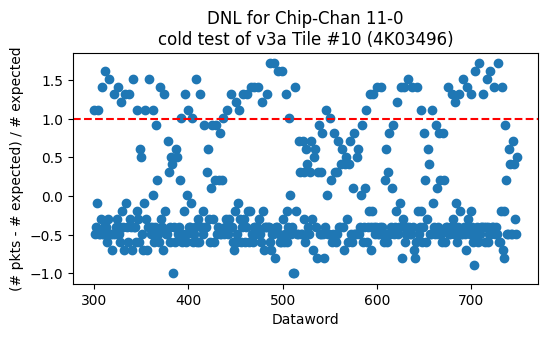

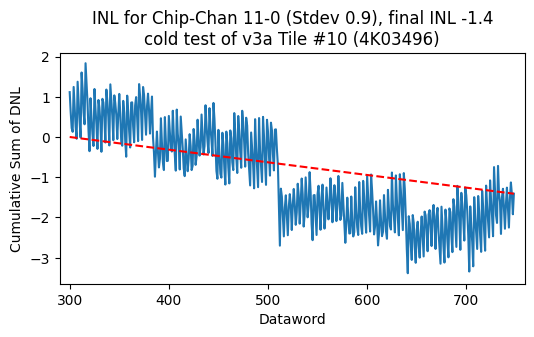

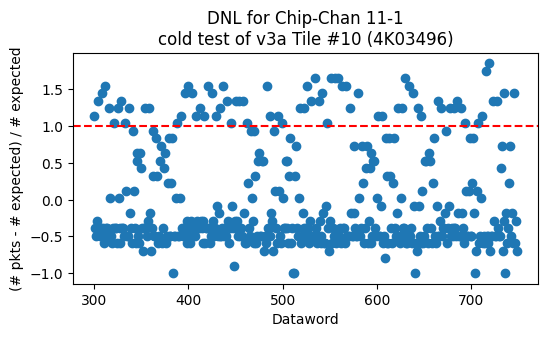

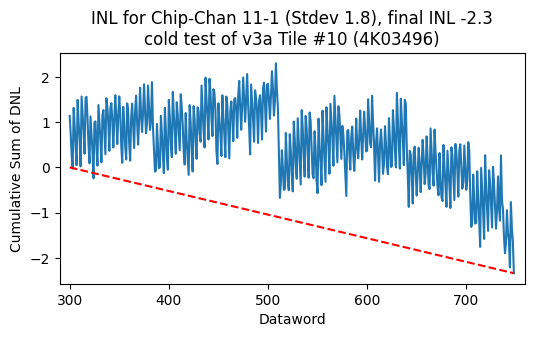

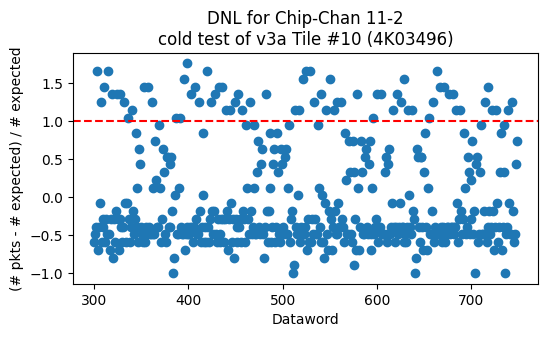

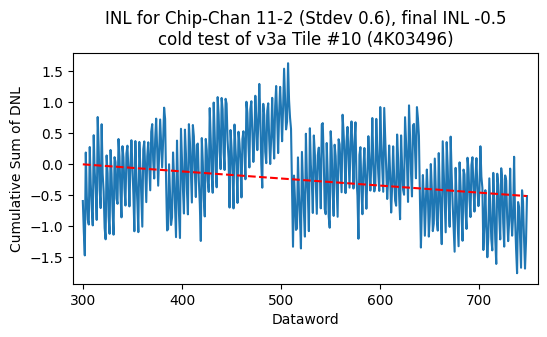

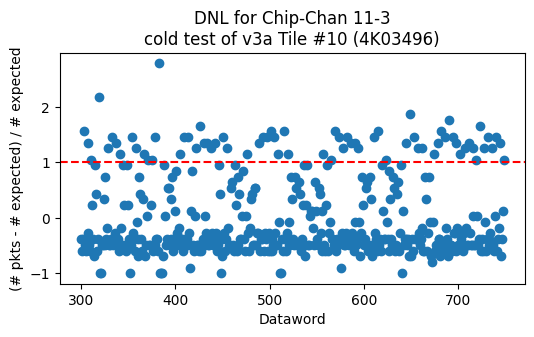

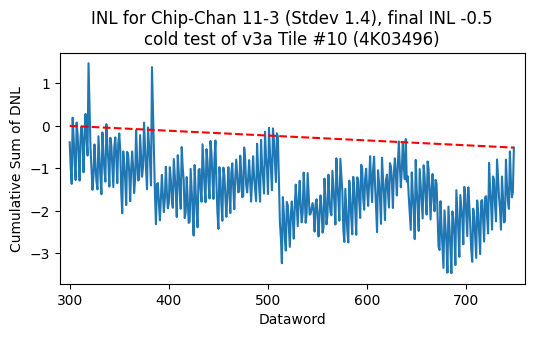

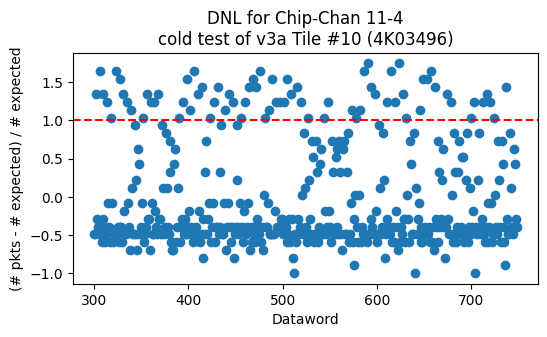

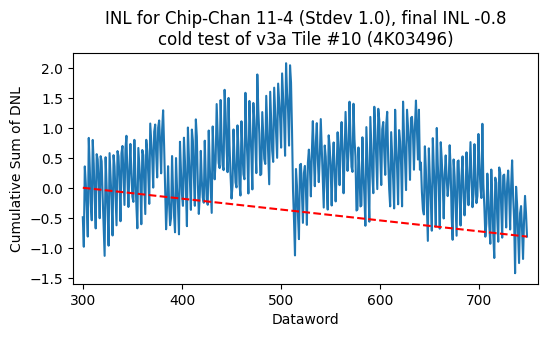

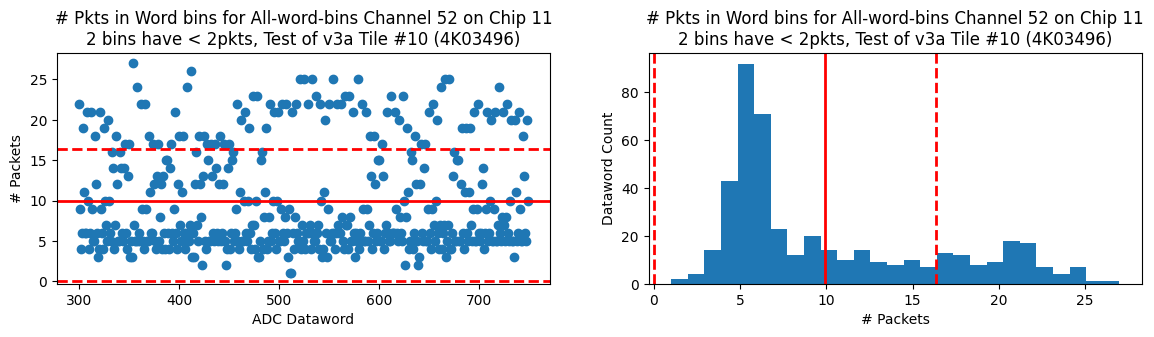

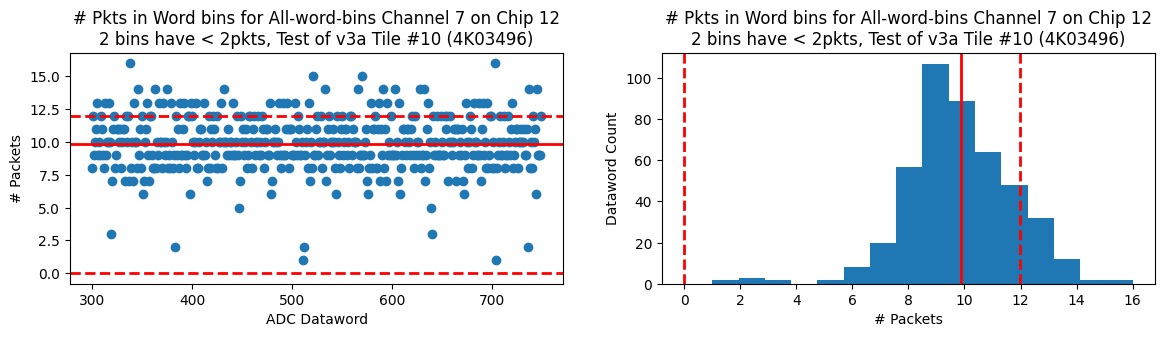

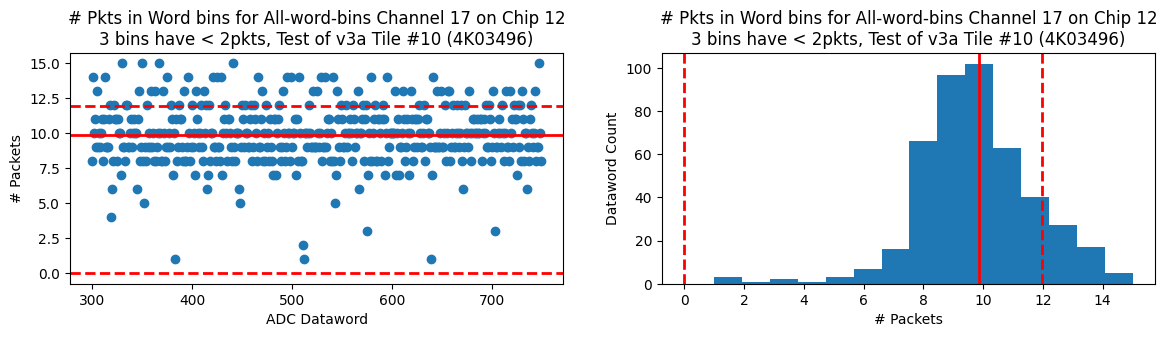

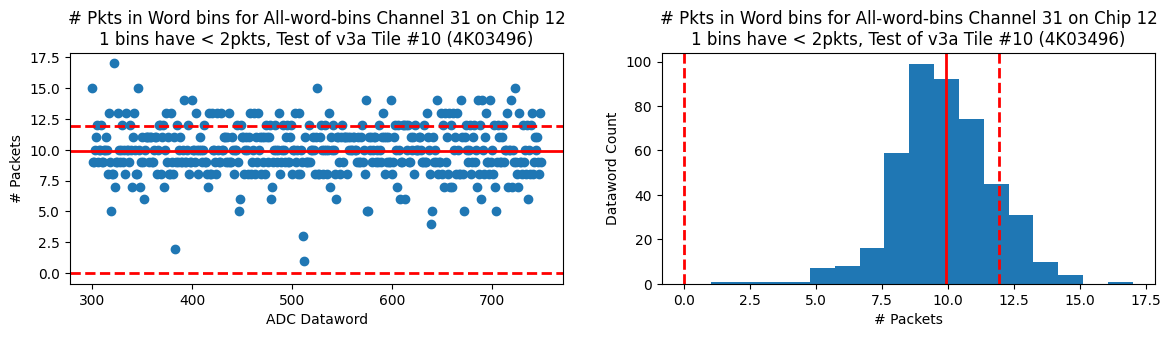

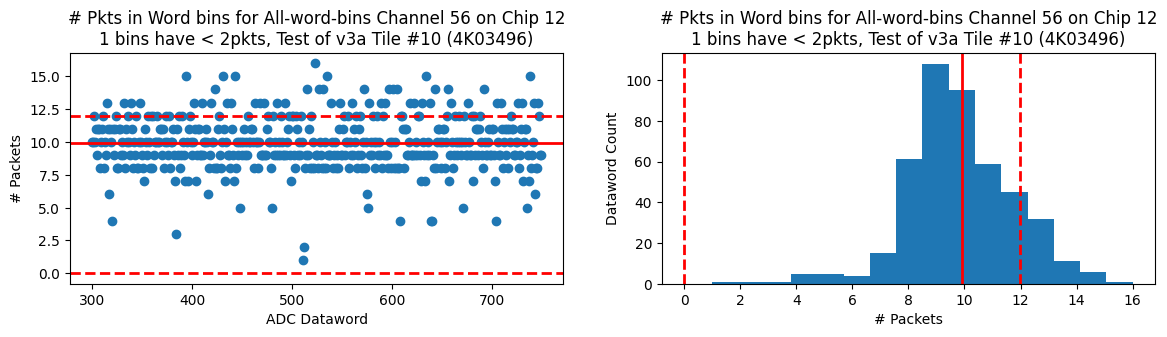

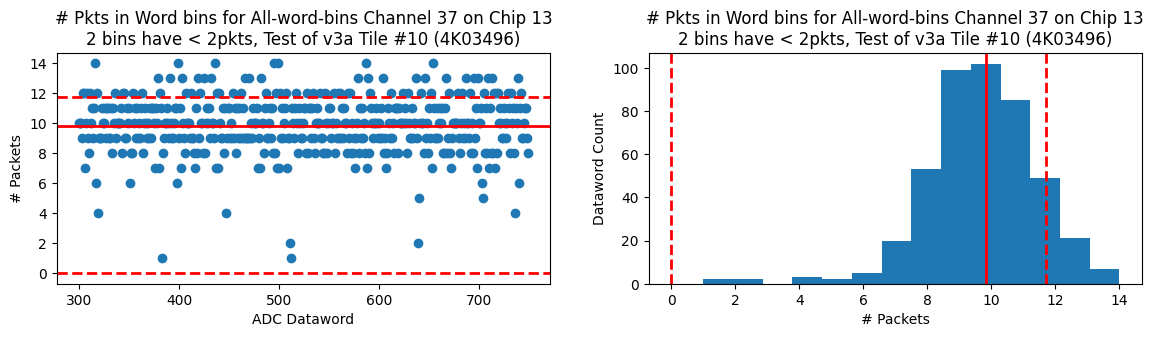

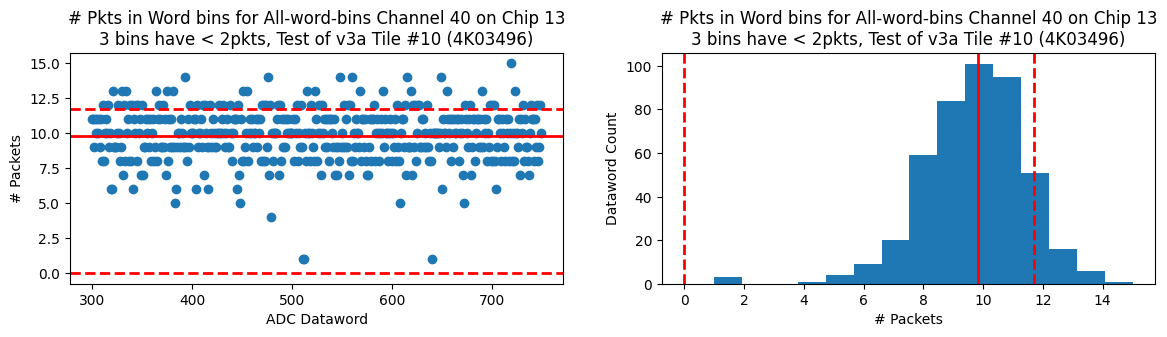

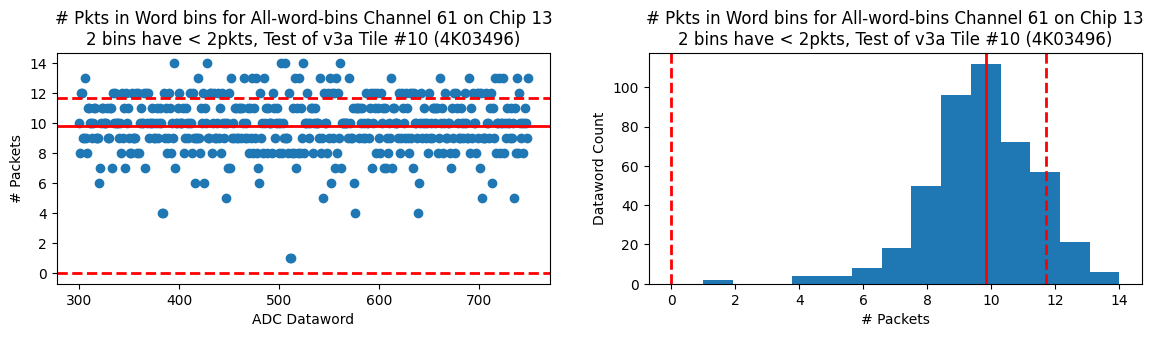

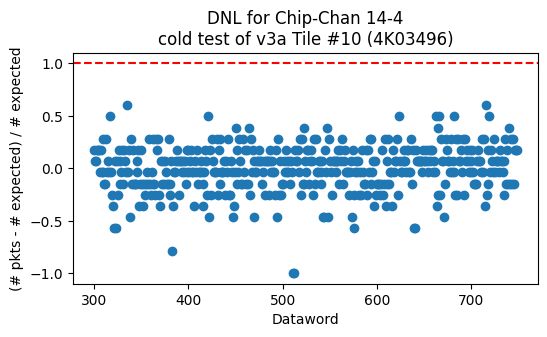

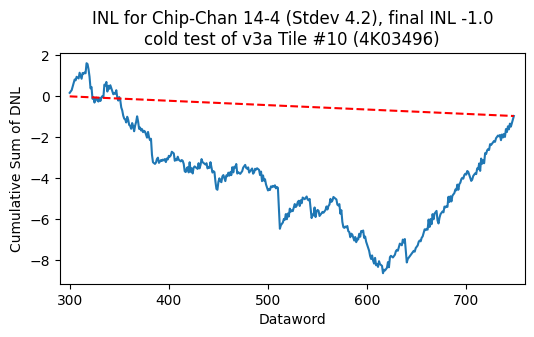

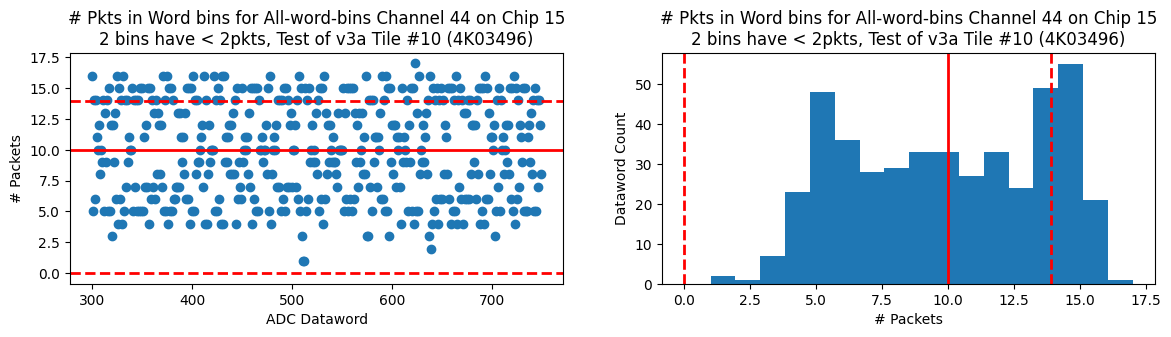

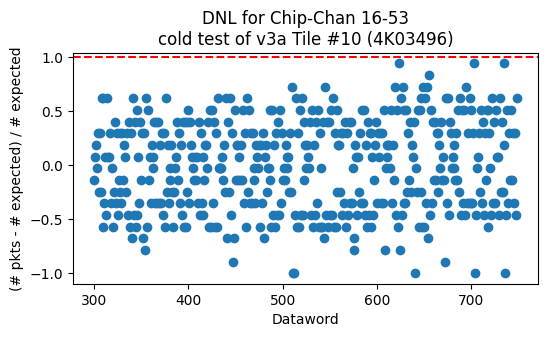

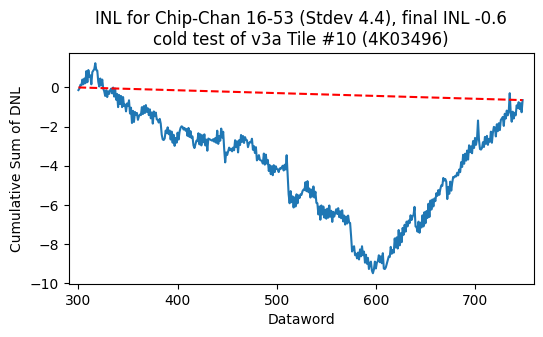

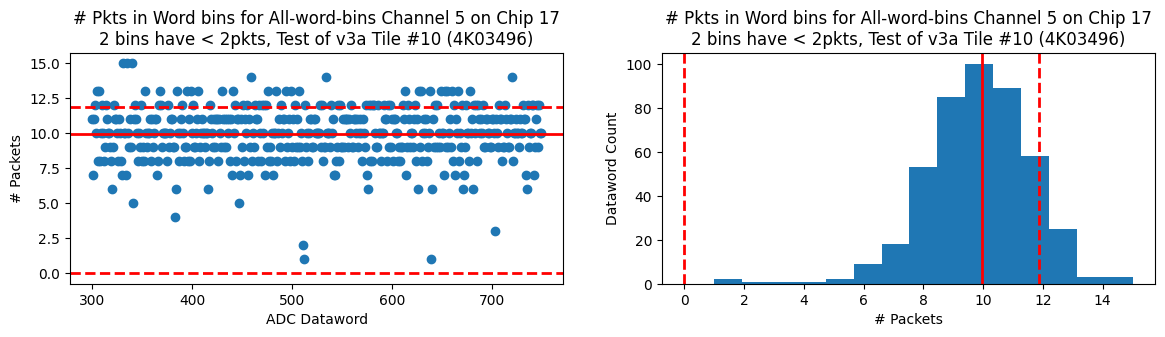

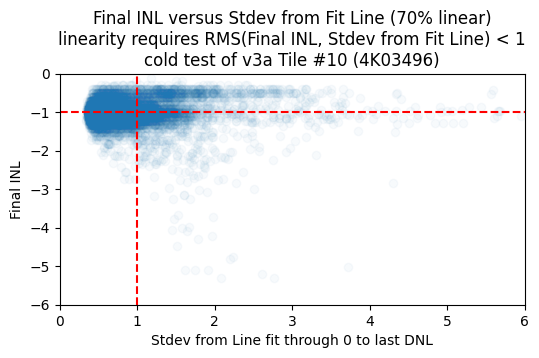

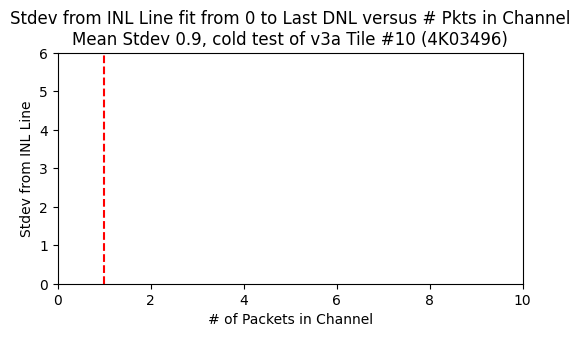

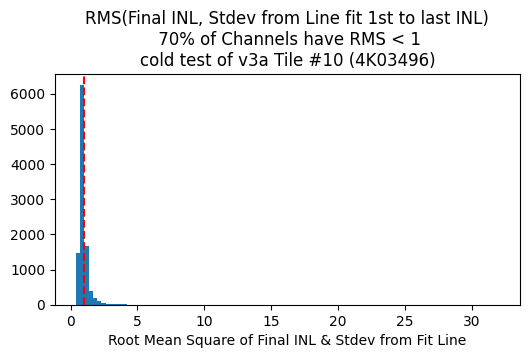

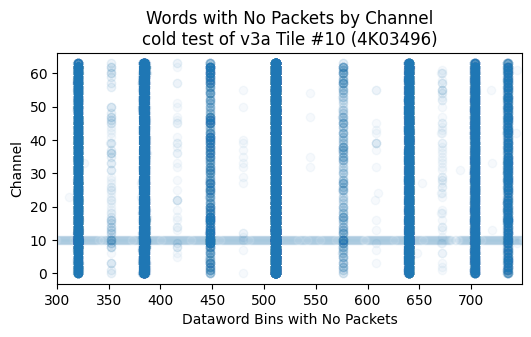

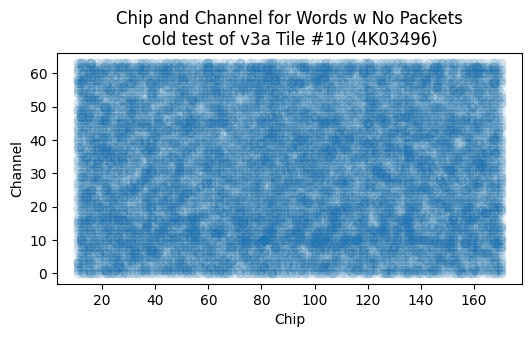

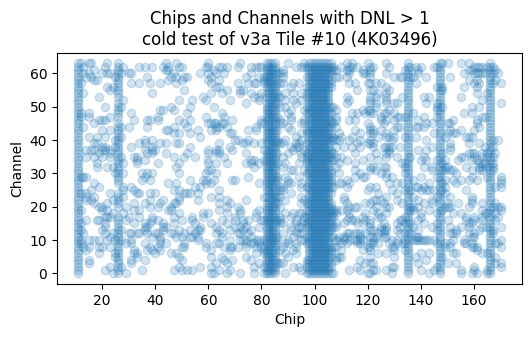

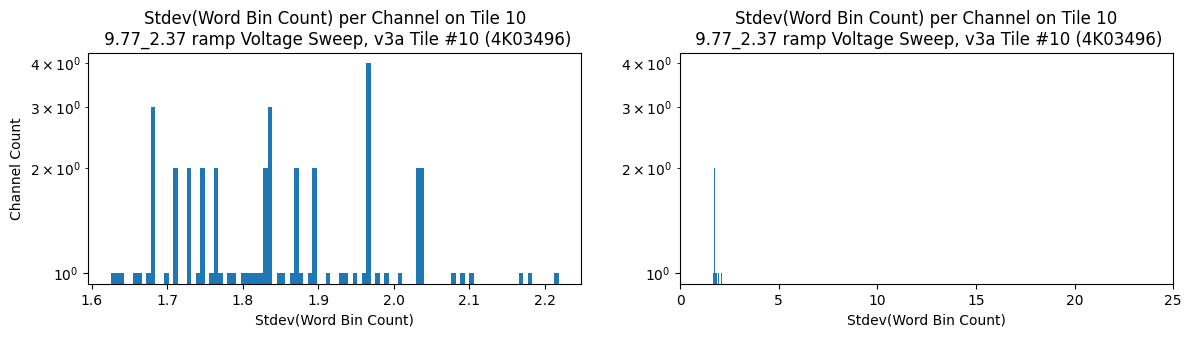

In [14]:
####################
# main
####################

# import the results dictionary that holds all test results for all tiles at the chmannel level 
import_results_dictionary()

# extract tile, ramp, tile_index, and chip_serial_number from the filename
get_file_details(filename)

# read pkt_count and too_few arrays data from the file created by previously running "linearity_get_data"
read_data()

# graph the distribution of sparse word counts by chip for the tile
graph_tile(tile)

'''
# find the best and worst chips in terms of sparse word counts
# for the worst chip find the best and worst channels
best_chip, worst_chip, best_chan, worst_chan = find_best_and_worst()

# graph the best and worst cases
graph_chip(tile, best_chip, "Best")
graph_chip(tile, worst_chip, "Worst")
graph_channel(tile, worst_chip, best_chan , "Best")
graph_channel(tile, worst_chip, worst_chan, "Worst")

'''

get_dnl_inl(tile)

# store the results from files that are not BAD in the results dictionary for all tiles
if "BAD" not in filename:
    store_results()
    x = 7
else:
    "No results recorded for this BAD run datafile:\n\t {datafle}]"

# get the standard deviation of packet counts per channel
get_std_pkt_count(tile)
